# Proyecto: Detección de Fraude con Tarjetas de Crédito
---

## Objetivo del notebook
Este es el primer paso: **Análisis Exploratorio de Datos (EDA)**. Vamos a:
- Cargar los datos de transacciones e identidad.
- Unirlos en un solo DataFrame.
- Examinar el desbalanceo de clases (pocos fraudes, muchos legítimos).
- Identificar valores nulos y columnas importantes.
- Visualizar algunas variables clave.

El EDA nos ayuda a entender con qué tipo de datos trabajamos antes de aplicar modelos de Machine Learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para que los gráficos se vean bien
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Para ver todas las columnas al imprimir
pd.set_option('display.max_columns', None)

print("✅ Librerías cargadas")

✅ Librerías cargadas


: 

## Carga de datos brutos
---
Tenemos dos archivos CSV principales:
- `train_transaction.csv`: contiene 590,540 filas y 394 columnas. Cada fila es una transacción. La columna `isFraud` indica si fue fraude (1) o no (0).
- `train_identity.csv`: contiene 144,233 filas y 41 columnas con información adicional sobre el usuario/dispositivo. No todas las transacciones tienen datos de identidad.

Cargamos ambos y mostramos sus dimensiones.

In [ ]:
# Rutas relativas (porque el notebook está en notebooks/, y data/ está un nivel arriba)
ruta_trans = '../data/raw/train_transaction.csv'
ruta_id = '../data/raw/train_identity.csv'

print("Cargando transacciones...")
df_trans = pd.read_csv(ruta_trans)
print(f"Shape transacciones: {df_trans.shape}")

print("Cargando identidades...")
df_id = pd.read_csv(ruta_id)
print(f"Shape identidades: {df_id.shape}")


Cargando transacciones...


## Unión de tablas (merge)
La clave común es `TransactionID`. Usamos `how='left'` porque queremos conservar **todas** las transacciones, aunque no tengan información de identidad. Así no perdemos datos.
Al unirlas, las columnas de identidad quedarán con valor `NaN` (nulo) para las transacciones sin identidad.

In [ ]:
# Unimos por TransactionID, manteniendo todas las transacciones
df = pd.merge(df_trans, df_id, on='TransactionID', how='left')
print(f"Dataset combinado: {df.shape}")
df.head()

Dataset combinado: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

## Ver el desbalanceo de la variable objetivo `isFraud`
---
En detección de fraudes, los casos positivos son extremadamente raros. Esto es un **desafío** porque los modelos estándar tienden a predecir siempre "no fraude" y obtendrían 99.8% de exactitud, pero serían inútiles. Por eso necesitamos métricas como **recall** y técnicas como **SMOTE** más adelante.

Transacciones fraudulentas: 20663 (3.4990%)
Transacciones legítimas: 569877 (96.5010%)


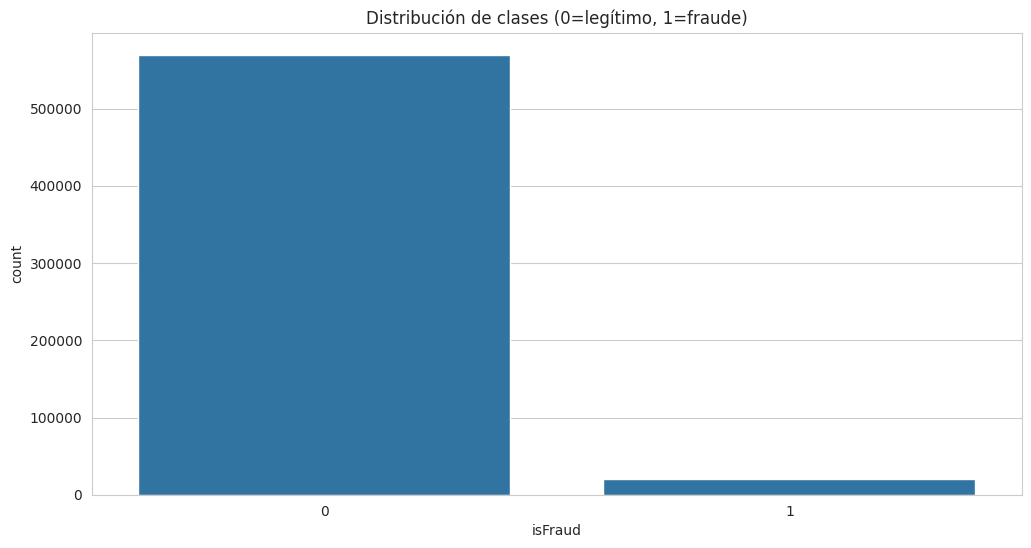

In [ ]:
fraudes = df['isFraud'].sum()
total = len(df)
print(f"Transacciones fraudulentas: {fraudes} ({fraudes/total:.4%})")
print(f"Transacciones legítimas: {total - fraudes} ({(total-fraudes)/total:.4%})")

# Gráfico de barras
sns.countplot(x='isFraud', data=df)
plt.title('Distribución de clases (0=legítimo, 1=fraude)')
plt.show()

## Valores nulos
---
Muchas columnas, especialmente las de identidad, tienen altos porcentajes de nulos. Debemos decidir más adelante si imputarlos, eliminarlos o usarlos de alguna forma. Por ahora solo vemos el panorama.

In [ ]:
nulos = df.isnull().mean() * 100
nulos_ordenados = nulos.sort_values(ascending=False)
print("Porcentaje de nulos por columna (primeras 20):")
print(nulos_ordenados.head(20))

Porcentaje de nulos por columna (primeras 20):
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
id_09    87.312290
dtype: float64


## Visualización de una variable numérica importante: `TransactionAmt`
---
El monto de la transacción puede ser un indicador de fraude. Por ejemplo, fraudes suelen tener montos atípicos (muy pequeños o muy grandes). Graficamos boxplot comparando legítimo vs fraude, con escala logarítmica porque hay valores extremos.

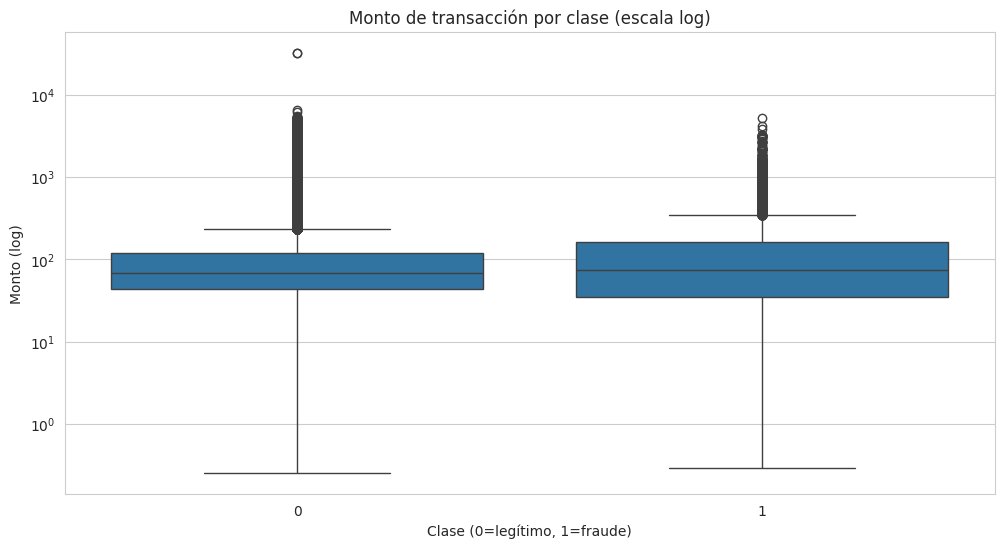

In [ ]:
plt.figure()
sns.boxplot(x='isFraud', y='TransactionAmt', data=df)
plt.yscale('log')
plt.title('Monto de transacción por clase (escala log)')
plt.xlabel('Clase (0=legítimo, 1=fraude)')
plt.ylabel('Monto (log)')
plt.show()

## Guardar el dataset combinado (opcional)
---
Para acelerar el trabajo futuro, guardamos el DataFrame resultante en formato Parquet (más rápido que CSV). No es obligatorio, pero si reiniciamos el notebook, podremos cargar este archivo en lugar de volver a hacer el merge.

In [ ]:
import os
os.makedirs('../data/processed', exist_ok=True)
df.to_parquet('../data/processed/train_combined.parquet', index=False)
print("Dataset guardado en data/processed/train_combined.parquet")

NameError: name 'df' is not defined